# Locality Index

### Imports

In [149]:
from __future__ import annotations
import networkx as nx
import numpy as np
import pytest
from abc import ABC, abstractmethod

### Error Classes

In [2]:
class NormalizationError(Exception):
    """Exception raised for errors in the normalization.

    Attributes:
        message -- explanation of the error
    """

    def __init__(self, message="An error occurred during normalization."):
        self.message = message
        super().__init__(self.message)

class NullGraphError(Exception):
    """Exception raised for null graph."""
    pass

class EmptyGraphError(Exception):
    """Exception raised for empty graph. Nodes with no edges."""
    pass


def check_raw_value(func):
    """Decorator to check if raw value is None. If it is, raise an error."""
    def wrapper(self, *args):
        if self._raw_value is not None:
            return func(self, *args)
        else:
            raise ValueError("Raw value is None. Call compute() method first.")
    return wrapper

### Abstract Class

In [3]:
class _Property(ABC):
    """Abstract base class for all properties."""
    _return_type = None
    _use_paths = False
    _use_direction = False
    _use_selfloops = False
    _use_giant_component = False

    def __init__(self, G: nx.DiGraph):
        self.G = G
        self._raw_value = None
        self._n_nodes = self.G.number_of_nodes()
        if self._n_nodes == 0:
            raise NullGraphError("Can not calculate subgraph centrality for inexistent nodes.")

    @abstractmethod
    def compute(self):
        return self._raw_value

    @abstractmethod
    def norm_biol(self, *args):
        pass

    @abstractmethod
    def norm_network(self, *args):
        pass

### Decorators

In [4]:
def use_direction(cls):
    cls._use_direction = True
    return cls

def use_selfloops(cls):
    cls._use_selfloops = True
    return cls

def use_giant_component(cls):
    cls._use_giant_component = True
    return cls

def return_scalar(cls):
    cls._return_type = "scalar"
    return cls

def return_distribution(cls):
    cls._return_type = "distribution"
    return cls

def use_paths(cls):
    cls._use_paths = True
    return cls

### Locality Index Class
The Locality Index of a node corresponds to the ratio between the number of links between its immediate neighbors (including itself if there is a self loop) divided by the number of edges to all of the neighbors (between them and to the rest of the network). [10.1209/0295-5075/85/48001]

It reflects internality of connections of neighbors to each node in the graph. The maximum theoretical value (1) is achieved when all connections involving a node's neighbors are between them. As connections between a node's neighbor and another node (one that is neighbor to the node being evaluated) increase, the locality index decreases and converges towards 0. [https://doi.org/10.48550/arXiv.1003.3084]

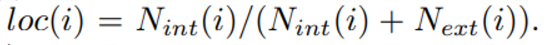

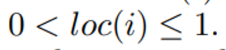

In [125]:
@return_distribution
@use_selfloops
class LocalityIndex(_Property): # Hereda de la clase _Property
    """Locality Index.

    Measurement that reflects the internality of every connection of all neighbors immediate to each node.
    It is calculated, for each node, as the number of links between that node's neighbors (including itself if there is a self-loop)
    divided by the total number of edges each of those neighbors is involved in.

    Methods:
        compute: Compute the locality index for every node in the graph.
        norm_biol: NO IMPLEMENTATION.
        norm_network: Normalize locality index for every node. Already normalized.
    """
    __name__ = 'Locality Index'
    
    def __init__(self, G: nx.DiGraph):
        """
        Args:
            G (nx.DiGraph): Graph.
        """
        super().__init__(G)

    def compute(self) -> np.array:
        """Compute the locality index for every node in the graph.

        Returns:
            nparray: locality index for every node.  
        """
        n_edges = self.G.number_of_edges()
        if n_edges == 0:
            raise EmptyGraphError("There are no edges. Can not calculate locality index of nodes that do not form any edges.")
        
        self.A = self.G.to_undirected()
        self._raw_value = []

        for node in self.A.nodes():
            #If there is a self-loop, you can be your own neighbor, if not, a connection to you is considered in n_ext
            neighbors = [x for x in self.A.neighbors(node)]

            links_neighbors = [self.A.number_of_edges(neighbors[i], neighbors[j]) for i in range(len(neighbors)) for j in range(i, len(neighbors))]

            n_int = np.fromiter(links_neighbors, dtype=int).sum()

            links_externals = [self.A.number_of_edges(i, j) for i in neighbors for x,j in self.A.edges(i) if j not in neighbors]

            n_ext = np.fromiter(links_externals, dtype=int).sum()
            
            self._raw_value.append(n_int / (n_int + n_ext))

        self._raw_value = np.asarray(self._raw_value, dtype=float)
        
        return self._raw_value

    @check_raw_value
    def norm_biol(self):
        """NO IMPLEMENTATION."""
        raise NormalizationError("No biological normalization implemented.")

    @check_raw_value
    def norm_network(self):
        """Already normalized."""
        return self._raw_value # Already normalized [0,1]

### Testing

In [152]:
# Null graph
G = nx.DiGraph()
with pytest.raises(NullGraphError) as e_info:
    property = LocalityIndex(G)

# Empty graph, allows instance from an empty graph, but does not compute
n_nodes= 5
G.add_nodes_from(range(n_nodes))
property = LocalityIndex(G)
with pytest.raises(EmptyGraphError) as e_info:
    property.compute()

# add edges
# complete directed graph with self loops
G.add_edges_from([(i, j) for i in range(n_nodes) for j in range(n_nodes)])
property = LocalityIndex(G)
expected = np.array([1., 1., 1., 1., 1.])

assert np.allclose(property.compute(), expected)
assert np.allclose(property.norm_network(), expected)
with pytest.raises(NormalizationError) as e_info:
    property.norm_biol()

# add edges
# only half of the nodes are parents and regulate every node in the graph
G = nx.DiGraph()
n_nodes= 5
G.add_nodes_from(range(n_nodes))
G.add_edges_from([(i, j) for i in range(n_nodes//2) for j in range(n_nodes)])
property = LocalityIndex(G)

expected = np.array([1.        , 1.        , 0.33333333, 0.33333333, 0.33333333])

assert np.allclose(property.compute(), expected)
assert np.allclose(property.norm_network(), expected)
with pytest.raises(NormalizationError) as e_info:
    property.norm_biol()

#add node 5
#add edge between 4 and 5
#4 is only neighbor of 5
G.add_node(5)
G.add_edge(4,5)
property = LocalityIndex(G)

expected = np.array([0.9, 0.9, 0.33333333, 0.33333333, 0.3, 0.])
mask = ~(np.isnan(property.compute()) | np.isnan(expected))
assert np.allclose(property.compute(), expected)
assert np.allclose(property.norm_network(), expected)
with pytest.raises(NormalizationError) as e_info:
    property.norm_biol()